# Data And Model Diagnostic Visualization

This notebook does not train a new model. It reads the cleaned dataset, prepared ML splits, and saved model outputs to visualize why current performance is limited by the available data/features rather than by a single model implementation.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import skew
from sklearn.metrics import mean_absolute_error, mean_squared_error, pairwise_distances, r2_score
from sklearn.preprocessing import PowerTransformer, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

BASE_DIR = Path.cwd()

TARGET_COL = "max_power_density_w_m2"
DATA_PATH = BASE_DIR / "MFC_dataset_checked_cleaned.csv"
ML_READY_DIR = BASE_DIR / "ml_ready"
RESULT_ROOT = BASE_DIR / "model_results"
DIAG_DIR = BASE_DIR / "diagnostic_visualizations"
DIAG_DIR.mkdir(parents=True, exist_ok=True)

RUNS = {
    "XGB 3D": RESULT_ROOT / "xgboost" / "pca_5d_iterative_extra_trees" / "yeo-johnson_random_split_full_100_trials",
    "CatBoost 3D": RESULT_ROOT / "catboost" / "pca_5d_iterative_extra_trees" / "yeo-johnson_random_split_full_100_trials",
    "ExtraTrees 3D": RESULT_ROOT / "extra_trees" / "pca_5d_iterative_extra_trees" / "yeo-johnson_random_split_full_100_trials",
    # "TabPFN 3D": RESULT_ROOT / "tabpfn" / "pca_5d_iterative_extra_trees" / "yeo-johnson_random_split_no_tuning",
}

MODEL_ORDER = list(RUNS)
MODEL_COLORS = dict(zip(MODEL_ORDER, sns.color_palette("tab10", n_colors=len(MODEL_ORDER)).as_hex()))
SPLIT_COLORS = {"cv": "#4C78A8", "train": "#F58518", "test": "#54A24B"}

TARGET_BINS = [-1e-9, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 100]
TARGET_BIN_LABELS = ["<=0.01", "0.01-0.05", "0.05-0.1", "0.1-0.2", "0.2-0.5", "0.5-1.0", "1.0-2.0", ">2.0"]
TARGET_BIN_DTYPE = pd.CategoricalDtype(TARGET_BIN_LABELS, ordered=True)

SOURCE_COLS = [
    "substrate_type",
    "initial_conc_g_cod_l",
    "anode_material",
    "anode_surface_area_m2",
    "anolyte_volume_ml",
    "cathode_material",
    "cathode_surface_area_m2",
    "catholyte_volume_ml",
    "pH",
    "temperature_c",
    "anode_S_V_ratio_m2_m3",
    "cathode_S_V_ratio_m2_m3",
]


def regression_metrics(y_true, y_pred) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_run(label: str, path: Path) -> dict:
    metrics = load_json(path / "metrics.json")
    train_pred = pd.read_csv(path / "train_predictions.csv", encoding="utf-8-sig")
    test_pred = pd.read_csv(path / "test_predictions.csv", encoding="utf-8-sig")
    importance = pd.read_csv(path / "feature_importance.csv", encoding="utf-8-sig") if (path / "feature_importance.csv").exists() else pd.DataFrame()
    return {"label": label, "path": path, "metrics": metrics, "train": train_pred, "test": test_pred, "importance": importance}


def ordered_loaded_models() -> list[str]:
    return [label for label in MODEL_ORDER if label in runs]


clean_df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
runs = {label: load_run(label, path) for label, path in RUNS.items() if path.exists()}
print(f"Clean data shape: {clean_df.shape}")
print(f"Loaded result runs: {ordered_loaded_models()}")



Clean data shape: (98, 13)
Loaded result runs: ['XGB 3D', 'CatBoost 3D', 'ExtraTrees 3D']


,target_space,skew,min,median,mean,max
0,original,2.193027,2.300000e-08,0.103000,2.260274e-01,1.600000
1,log1p,1.714338,2.300000e-08,0.098032,1.788479e-01,0.955511
2,yeo-johnson,0.486223,-1.358335e+00,-0.175008,9.063045e-17,1.913907
3,box-cox,-0.021377,-2.764807e+00,-0.038735,-1.738972e-16,2.333909


,target_bin,n
0,<=0.01,9
1,0.01-0.05,22
2,0.05-0.1,17
3,0.1-0.2,18
4,0.2-0.5,17
5,0.5-1.0,12
6,1.0-2.0,3
7,>2.0,0


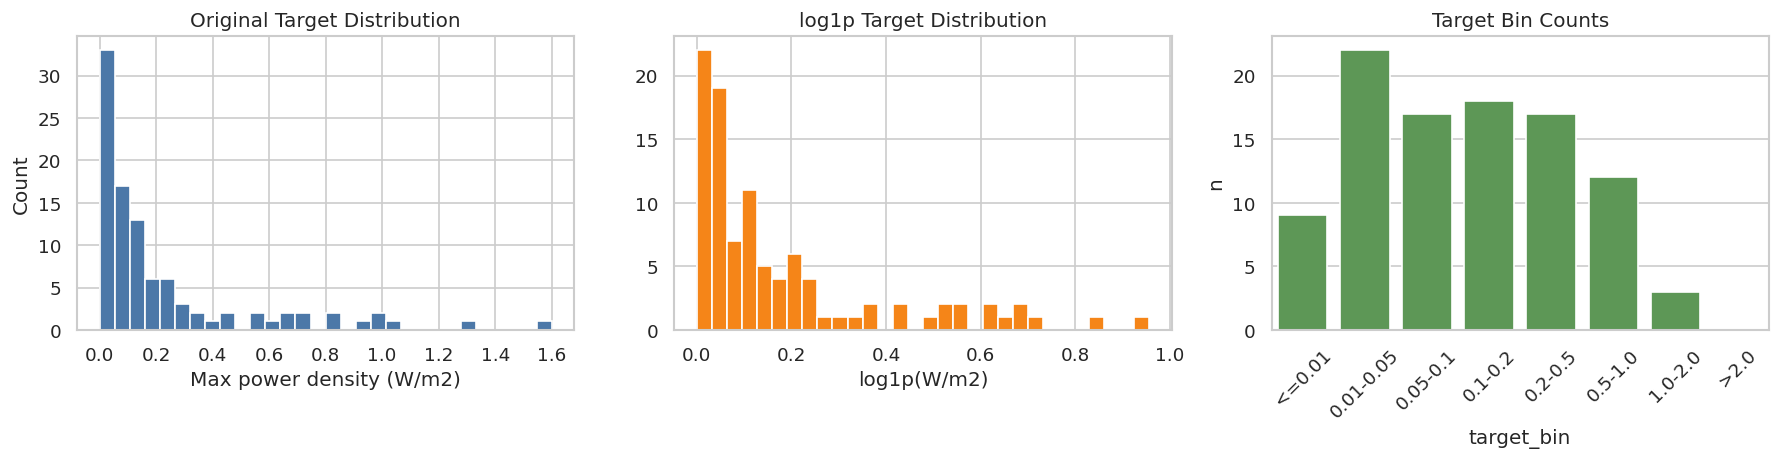

In [2]:
y = clean_df[TARGET_COL].astype(float).to_numpy().reshape(-1, 1)
transforms = {
    "original": y.ravel(),
    "log1p": np.log1p(y.ravel()),
    "yeo-johnson": PowerTransformer(method="yeo-johnson", standardize=True).fit_transform(y).ravel(),
    "box-cox": PowerTransformer(method="box-cox", standardize=True).fit_transform(y).ravel(),
}
skew_table = pd.DataFrame([
    {
        "target_space": name,
        "skew": float(skew(values, bias=False)),
        "min": float(values.min()),
        "median": float(np.median(values)),
        "mean": float(values.mean()),
        "max": float(values.max()),
    }
    for name, values in transforms.items()
])
clean_df["target_bin"] = pd.cut(clean_df[TARGET_COL], TARGET_BINS, labels=TARGET_BIN_LABELS)
bin_counts = clean_df["target_bin"].value_counts().sort_index().reset_index()
bin_counts.columns = ["target_bin", "n"]

display(skew_table)
display(bin_counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(clean_df[TARGET_COL], bins=30, color="#4C78A8")
axes[0].set_title("Original Target Distribution")
axes[0].set_xlabel("Max power density (W/m2)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(clean_df[TARGET_COL]), bins=30, color="#F58518")
axes[1].set_title("log1p Target Distribution")
axes[1].set_xlabel("log1p(W/m2)")

sns.barplot(data=bin_counts, x="target_bin", y="n", ax=axes[2], color="#54A24B")
axes[2].set_title("Target Bin Counts")
axes[2].tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(DIAG_DIR / "01_target_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

,model,overlap,cv_mae,cv_rmse,cv_r2,cv_std_mae,train_mae,train_rmse,train_r2,test_mae,test_rmse,test_r2
2,ExtraTrees 3D,0,0.154270,0.275343,0.203383,0.028711,0.018345,0.070235,0.950684,0.060858,0.071436,0.927661
0,XGB 3D,0,0.156951,0.276823,0.178544,0.023345,0.086804,0.190914,0.635622,0.072885,0.107215,0.837050
1,CatBoost 3D,0,0.149940,0.267151,0.240512,0.021381,0.056051,0.119769,0.856594,0.091987,0.164143,0.618066


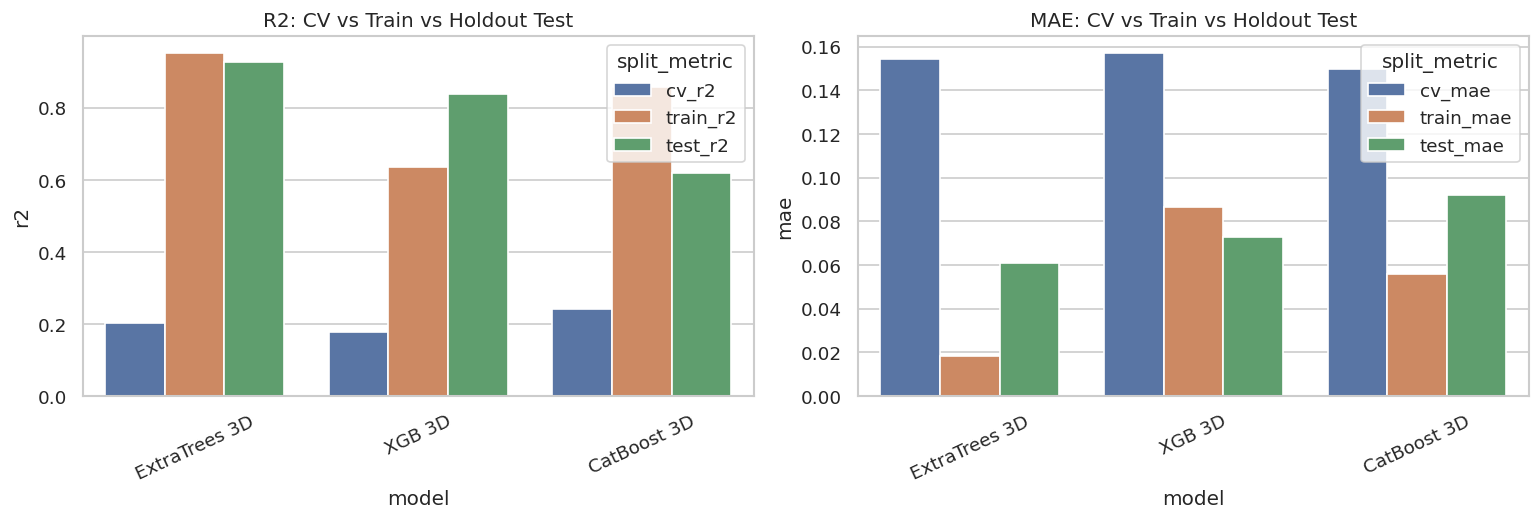

In [3]:
metric_rows = []
for label, run in runs.items():
    metrics = run["metrics"]
    row = {
        "model": label,
        "overlap": metrics.get("input_signature_overlap_audit"),
        "cv_mae": metrics["cv"]["best_cv_mean_mae"],
        "cv_rmse": metrics["cv"]["best_cv_mean_rmse"],
        "cv_r2": metrics["cv"]["best_cv_mean_r2"],
        "cv_std_mae": metrics["cv"]["best_cv_std_mae"],
        "train_mae": metrics["train"]["mae"],
        "train_rmse": metrics["train"]["rmse"],
        "train_r2": metrics["train"]["r2"],
        "test_mae": metrics["test"]["mae"],
        "test_rmse": metrics["test"]["rmse"],
        "test_r2": metrics["test"]["r2"],
    }
    metric_rows.append(row)
metrics_df = pd.DataFrame(metric_rows).sort_values("test_r2", ascending=False)
display(metrics_df)

plot_df = metrics_df.melt(id_vars="model", value_vars=["cv_r2", "train_r2", "test_r2"], var_name="split_metric", value_name="r2")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=plot_df, x="model", y="r2", hue="split_metric", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("R2: CV vs Train vs Holdout Test")
axes[0].tick_params(axis="x", rotation=25)

mae_df = metrics_df.melt(id_vars="model", value_vars=["cv_mae", "train_mae", "test_mae"], var_name="split_metric", value_name="mae")
sns.barplot(data=mae_df, x="model", y="mae", hue="split_metric", ax=axes[1])
axes[1].set_title("MAE: CV vs Train vs Holdout Test")
axes[1].tick_params(axis="x", rotation=25)

fig.tight_layout()
fig.savefig(DIAG_DIR / "02_model_metric_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

,model,split,n,actual_min,actual_median,actual_mean,actual_max,actual_std,pred_min,pred_median,pred_mean,pred_max,pred_std,pred_range_ratio,top1_sse_share,top3_sse_share
0,XGB 3D,train,83,1.047000e-04,0.10920,0.236386,1.6,0.316273,0.017199,0.117522,0.210154,1.518975,0.287486,0.938671,0.356598,0.611194
1,XGB 3D,test,15,2.300000e-08,0.05925,0.168711,1.0,0.265600,0.014576,0.075781,0.198844,1.327095,0.325526,1.312520,0.620507,0.868821
2,CatBoost 3D,train,83,1.047000e-04,0.10920,0.236386,1.6,0.316273,0.009929,0.115995,0.208162,1.209727,0.256326,0.749923,0.304906,0.616378
3,CatBoost 3D,test,15,2.300000e-08,0.05925,0.168711,1.0,0.265600,0.021672,0.091750,0.222452,1.581926,0.385715,1.560254,0.837911,0.925143
4,ExtraTrees 3D,train,83,1.047000e-04,0.10920,0.236386,1.6,0.316273,0.002029,0.110533,0.222743,1.054840,0.273405,0.658050,0.800440,0.962214
5,ExtraTrees 3D,test,15,2.300000e-08,0.05925,0.168711,1.0,0.265600,0.028357,0.097133,0.196026,1.025736,0.268930,0.997379,0.204980,0.529210


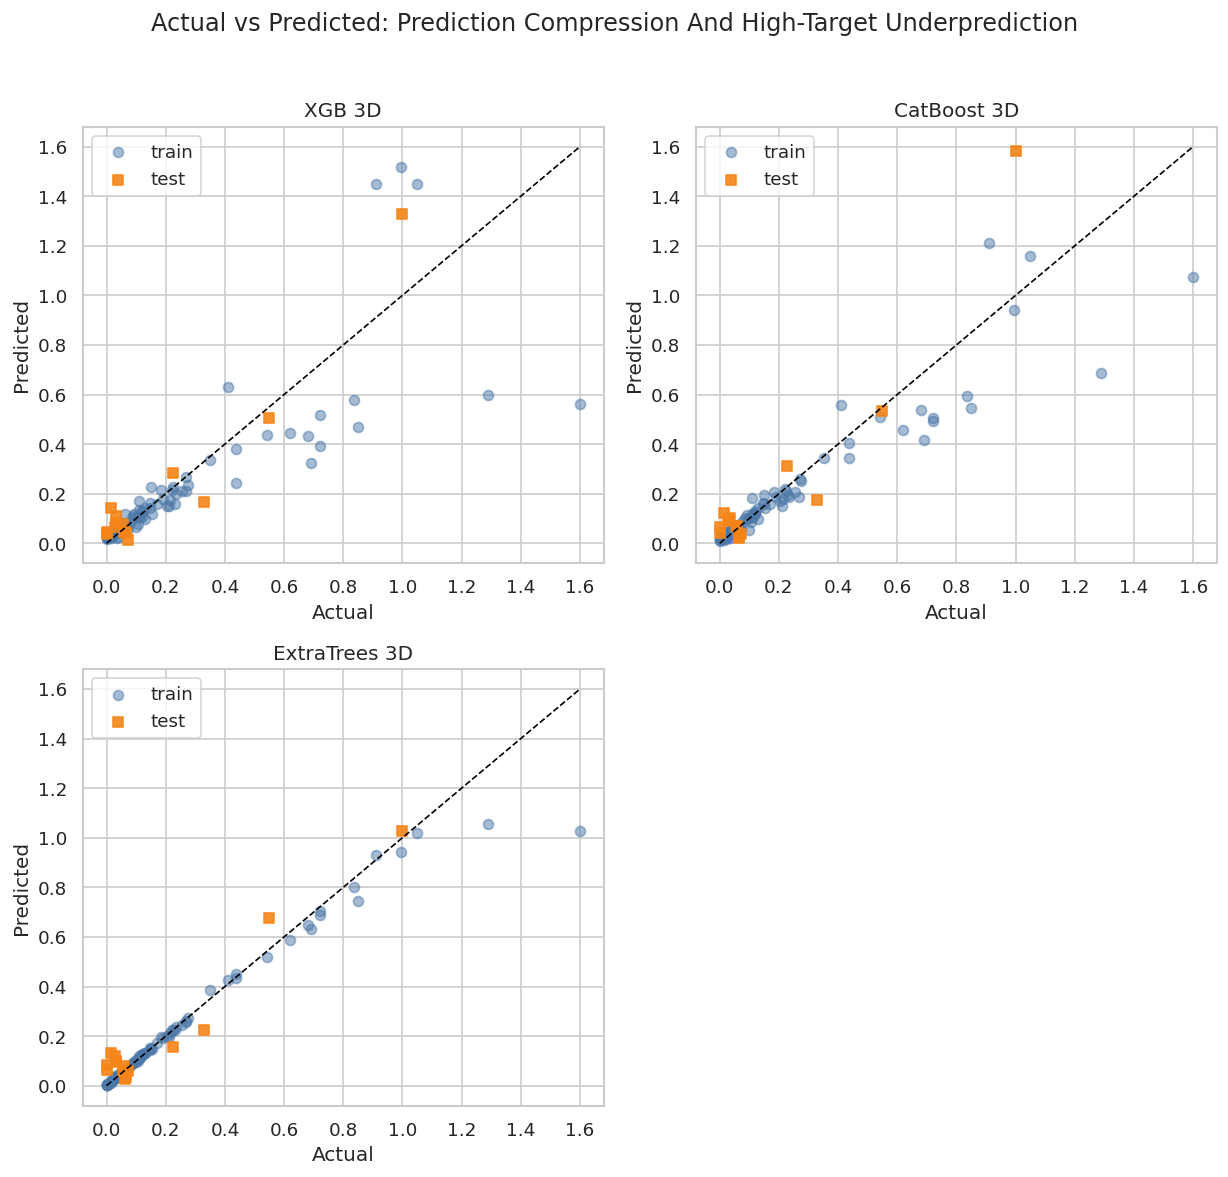

In [4]:
diag_rows = []
for label in ordered_loaded_models():
    run = runs[label]
    for split_name in ["train", "test"]:
        df = run[split_name].copy()
        y_true = df["actual"].to_numpy(dtype=float)
        y_pred = df["predicted"].to_numpy(dtype=float)
        sse = np.square(y_true - y_pred)
        diag_rows.append({
            "model": label,
            "split": split_name,
            "n": len(df),
            "actual_min": y_true.min(),
            "actual_median": np.median(y_true),
            "actual_mean": y_true.mean(),
            "actual_max": y_true.max(),
            "actual_std": y_true.std(ddof=0),
            "pred_min": y_pred.min(),
            "pred_median": np.median(y_pred),
            "pred_mean": y_pred.mean(),
            "pred_max": y_pred.max(),
            "pred_std": y_pred.std(ddof=0),
            "pred_range_ratio": (y_pred.max() - y_pred.min()) / (y_true.max() - y_true.min()) if (y_true.max() - y_true.min()) else np.nan,
            "top1_sse_share": sse.max() / sse.sum() if sse.sum() else np.nan,
            "top3_sse_share": np.sort(sse)[-3:].sum() / sse.sum() if sse.sum() else np.nan,
        })
diag_df = pd.DataFrame(diag_rows)
display(diag_df)

model_labels = ordered_loaded_models()
n_models = len(model_labels)
ncols = 3 if n_models > 4 else 2
nrows = math.ceil(n_models / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.8 * nrows), squeeze=False)
axes = axes.ravel()

for ax, label in zip(axes, model_labels):
    run = runs[label]
    for split_name, marker, alpha, color in [("train", "o", 0.50, "#4C78A8"), ("test", "s", 0.90, "#F58518")]:
        df = run[split_name]
        ax.scatter(df["actual"], df["predicted"], label=split_name, marker=marker, alpha=alpha, color=color)
    min_value = min(run["train"]["actual"].min(), run["test"]["actual"].min(), run["train"]["predicted"].min(), run["test"]["predicted"].min())
    max_value = max(run["train"]["actual"].max(), run["test"]["actual"].max(), run["train"]["predicted"].max(), run["test"]["predicted"].max())
    ax.plot([min_value, max_value], [min_value, max_value], "--", color="black", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend()

for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle("Actual vs Predicted: Prediction Compression And High-Target Underprediction", y=1.02)
fig.tight_layout()
fig.savefig(DIAG_DIR / "03_actual_vs_predicted_compression.png", dpi=200, bbox_inches="tight")
plt.show()


,model,target_bin,n,actual_mean,predicted_mean,mean_bias_pred_minus_actual,underprediction_rate,mae,rmse,r2
5,CatBoost 3D,<=0.01,2,0.000400,0.053303,0.052903,0.0,0.052903,0.054152,-18327.927438
10,ExtraTrees 3D,<=0.01,2,0.000400,0.073536,0.073136,0.0,0.073136,0.074069,-34289.380202
0,XGB 3D,<=0.01,2,0.000400,0.041715,0.041315,0.0,0.041315,0.041365,-10693.588175
6,CatBoost 3D,0.01-0.05,4,0.027143,0.101575,0.074432,0.0,0.074432,0.076778,-117.933742
11,ExtraTrees 3D,0.01-0.05,4,0.027143,0.112479,0.085337,0.0,0.085337,0.087969,-155.132914
1,XGB 3D,0.01-0.05,4,0.027143,0.098805,0.071663,0.0,0.071663,0.079657,-127.019886
7,CatBoost 3D,0.05-0.1,5,0.063260,0.044679,-0.018581,0.6,0.027768,0.030925,-34.647642
12,ExtraTrees 3D,0.05-0.1,5,0.063260,0.051991,-0.011269,0.6,0.020341,0.023486,-19.561613
2,XGB 3D,0.05-0.1,5,0.063260,0.044508,-0.018752,0.8,0.026585,0.030786,-34.329771
8,CatBoost 3D,0.2-0.5,2,0.277500,0.242524,-0.034976,0.5,0.119504,0.124518,-4.845842


,model,actual,predicted,abs_error,sse_share,substrate_type,anode_material,cathode_material
0,XGB 3D,1.000000e+00,1.327095,0.327095,0.620507,sodium acetate,flame-oxidized stainless steel (fo-ss) fiber felt,pt/c-modified carbon paper
1,XGB 3D,3.290000e-01,0.165373,0.163627,0.155277,sodium acetate,graphite felt,platinum coated carbon cloth
2,XGB 3D,1.520000e-02,0.141857,0.126657,0.093037,propanethiol,carbon brush,platinum
3,XGB 3D,3.300000e-02,0.108373,0.075373,0.032948,acetate,graphite rod,graphite rod
4,XGB 3D,2.260000e-01,0.282670,0.056670,0.018626,palm oil mill effluent,polyacryl nitrile carbon felt,polyacryl nitrile carbon felt
5,CatBoost 3D,1.000000e+00,1.581926,0.581926,0.837911,sodium acetate,flame-oxidized stainless steel (fo-ss) fiber felt,pt/c-modified carbon paper
6,CatBoost 3D,3.290000e-01,0.174519,0.154481,0.059049,sodium acetate,graphite felt,platinum coated carbon cloth
7,CatBoost 3D,1.520000e-02,0.121924,0.106724,0.028183,propanethiol,carbon brush,platinum
8,CatBoost 3D,2.260000e-01,0.310528,0.084528,0.017679,palm oil mill effluent,polyacryl nitrile carbon felt,polyacryl nitrile carbon felt
9,CatBoost 3D,3.300000e-02,0.100771,0.067771,0.011365,acetate,graphite rod,graphite rod


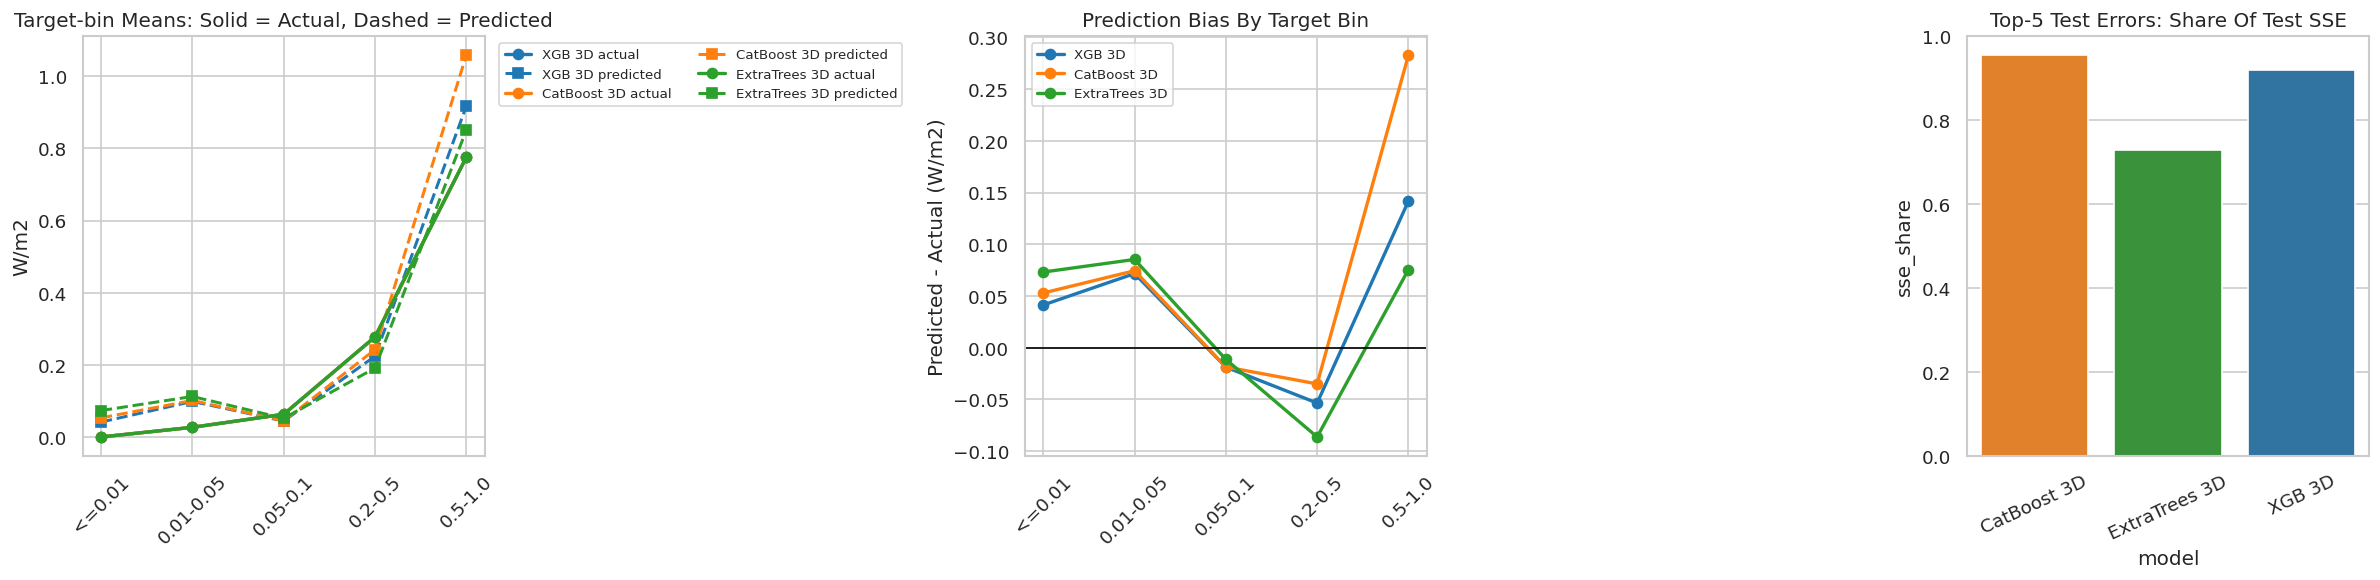

In [5]:
bin_rows = []
top_error_rows = []
for label in ordered_loaded_models():
    run = runs[label]
    test = run["test"].copy()
    test["target_bin"] = pd.cut(test["actual"], TARGET_BINS, labels=TARGET_BIN_LABELS).astype(TARGET_BIN_DTYPE)
    test["abs_error"] = (test["actual"] - test["predicted"]).abs()
    test["signed_error"] = test["predicted"] - test["actual"]
    test["squared_error"] = np.square(test["actual"] - test["predicted"])
    total_sse = test["squared_error"].sum()
    for target_bin, group in test.groupby("target_bin", observed=False):
        if len(group) == 0:
            continue
        metrics = regression_metrics(group["actual"], group["predicted"]) if len(group) > 1 else {
            "mae": float(mean_absolute_error(group["actual"], group["predicted"])),
            "rmse": float(np.sqrt(mean_squared_error(group["actual"], group["predicted"]))),
            "r2": np.nan,
        }
        bin_rows.append({
            "model": label,
            "target_bin": str(target_bin),
            "n": len(group),
            "actual_mean": group["actual"].mean(),
            "predicted_mean": group["predicted"].mean(),
            "mean_bias_pred_minus_actual": group["signed_error"].mean(),
            "underprediction_rate": float((group["signed_error"] < 0).mean()),
            "mae": metrics["mae"],
            "rmse": metrics["rmse"],
            "r2": metrics["r2"],
        })
    top = test.sort_values("squared_error", ascending=False).head(5).copy()
    top["model"] = label
    top["sse_share"] = top["squared_error"] / total_sse
    top_error_rows.append(top)

bin_metrics_df = pd.DataFrame(bin_rows)
bin_metrics_df["target_bin"] = bin_metrics_df["target_bin"].astype(TARGET_BIN_DTYPE)
top_errors_df = pd.concat(top_error_rows, ignore_index=True)
display(bin_metrics_df.sort_values(["target_bin", "model"]))
display(top_errors_df[["model", "actual", "predicted", "abs_error", "sse_share", "substrate_type", "anode_material", "cathode_material"]])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for label in ordered_loaded_models():
    sub = bin_metrics_df[bin_metrics_df["model"] == label].sort_values("target_bin")
    color = MODEL_COLORS[label]
    axes[0].plot(sub["target_bin"].astype(str), sub["actual_mean"], marker="o", color=color, linewidth=2.0, label=f"{label} actual")
    axes[0].plot(sub["target_bin"].astype(str), sub["predicted_mean"], marker="s", color=color, linestyle="--", linewidth=1.8, label=f"{label} predicted")
    axes[1].plot(sub["target_bin"].astype(str), sub["mean_bias_pred_minus_actual"], marker="o", color=color, linewidth=2.0, label=label)

axes[0].set_title("Target-bin Means: Solid = Actual, Dashed = Predicted")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("W/m2")
axes[0].legend(fontsize=8, ncol=2, loc="upper left", bbox_to_anchor=(1.02, 1.0))

axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Prediction Bias By Target Bin")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylabel("Predicted - Actual (W/m2)")
axes[1].legend(fontsize=8)

top_sse = top_errors_df.groupby("model", as_index=False)["sse_share"].sum()
sns.barplot(data=top_sse, x="model", y="sse_share", ax=axes[2], palette=MODEL_COLORS, hue="model", dodge=False, legend=False)
axes[2].set_title("Top-5 Test Errors: Share Of Test SSE")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis="x", rotation=25)

fig.tight_layout()
fig.savefig(DIAG_DIR / "04_bin_errors_and_sse_concentration.png", dpi=200, bbox_inches="tight")
plt.show()


,model,group,importance_value
2,CatBoost 3D,original numeric,42.186773
3,CatBoost 3D,substrate embedding,26.289357
0,CatBoost 3D,anode embedding,15.991299
1,CatBoost 3D,cathode embedding,15.532572
7,ExtraTrees 3D,substrate embedding,0.323285
6,ExtraTrees 3D,original numeric,0.322283
4,ExtraTrees 3D,anode embedding,0.181376
5,ExtraTrees 3D,cathode embedding,0.173056
10,XGB 3D,original numeric,0.440092
11,XGB 3D,substrate embedding,0.205355


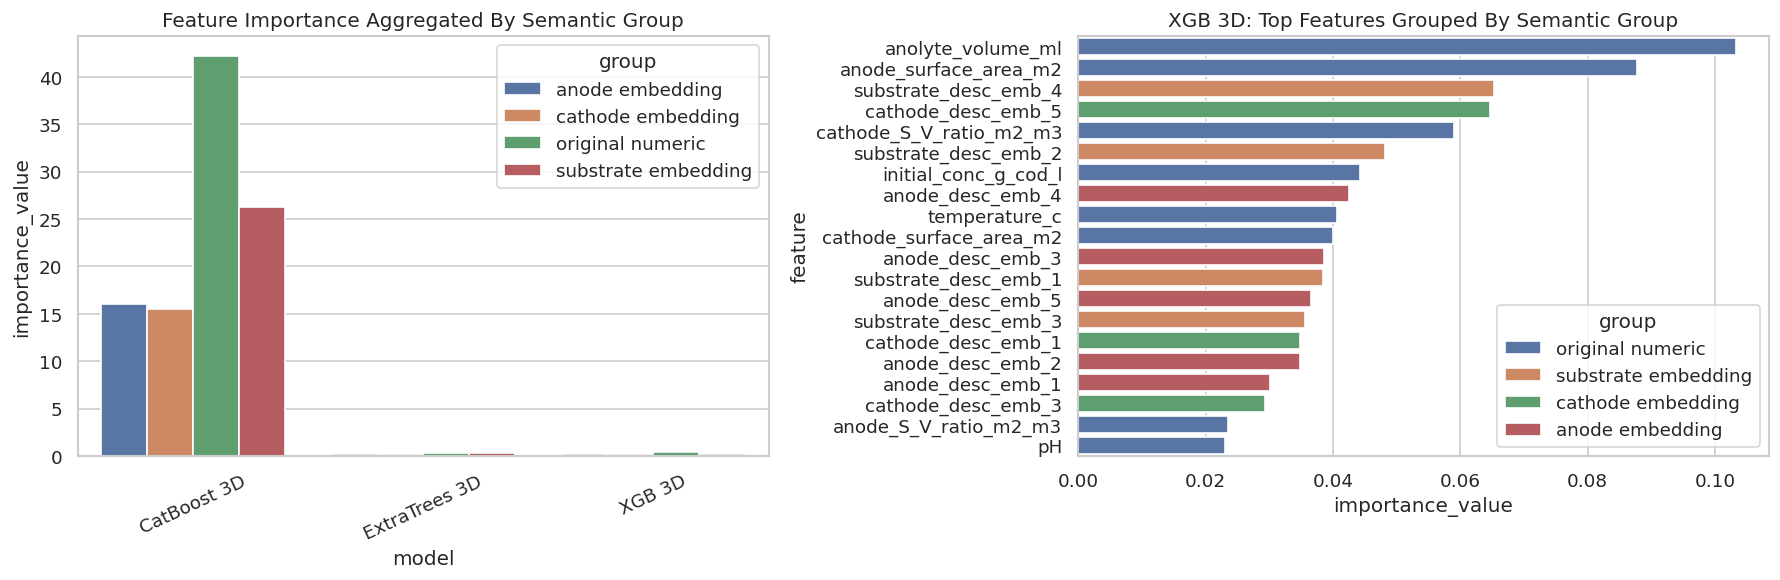

In [6]:
def feature_group(feature: str) -> str:
    if "substrate_desc" in feature:
        return "substrate embedding"
    if "anode_desc" in feature:
        return "anode embedding"
    if "cathode_desc" in feature:
        return "cathode embedding"
    duplicate_scale = {"anolyte_volume_l", "catholyte_volume_l"}
    derived_physical = {
        "total_liquid_volume_l",
        "total_electrode_area_m2",
        "cod_load_g",
        "anode_area_per_anolyte_l_m2_l",
        "cathode_area_per_catholyte_l_m2_l",
        "total_area_per_total_volume_l_m2_l",
        "anode_to_cathode_area_ratio",
        "anolyte_to_catholyte_volume_ratio",
        "cod_load_per_anode_area_g_m2",
        "cod_load_per_cathode_area_g_m2",
    }
    if feature in duplicate_scale:
        return "duplicate scale feature"
    if feature in derived_physical:
        return "derived physical feature"
    return "original numeric"

importance_rows = []
for label, run in runs.items():
    imp = run["importance"].copy()
    if imp.empty:
        continue
    importance_col = "importance" if "importance" in imp.columns else "importance_mae_increase_mean"
    imp["importance_value"] = imp[importance_col]
    imp["model"] = label
    imp["group"] = imp["feature"].map(feature_group)
    importance_rows.append(imp[["model", "feature", "group", "importance_value"]])
importance_df = pd.concat(importance_rows, ignore_index=True)
importance_group_df = importance_df.groupby(["model", "group"], as_index=False)["importance_value"].sum()
display(importance_group_df.sort_values(["model", "importance_value"], ascending=[True, False]))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=importance_group_df, x="model", y="importance_value", hue="group", ax=axes[0])
axes[0].set_title("Feature Importance Aggregated By Semantic Group")
axes[0].tick_params(axis="x", rotation=25)

xgb_phys_label = "XGB 5D + physical" if "XGB 5D + physical" in ordered_loaded_models() else (model_labels[0] if len(model_labels) > 0 else "")
xgb_phys_imp = importance_df[importance_df["model"] == xgb_phys_label].sort_values("importance_value", ascending=False).head(20)
if not xgb_phys_imp.empty:
    sns.barplot(data=xgb_phys_imp, x="importance_value", y="feature", hue="group", dodge=False, ax=axes[1])
else:
    axes[1].text(0.5, 0.5, "No physical model runs loaded", ha="center", va="center")
axes[1].set_title(f"{xgb_phys_label}: Top Features Grouped By Semantic Group" if not xgb_phys_imp.empty else "Physical model diagnostics")

fig.tight_layout()
fig.savefig(DIAG_DIR / "05_feature_importance_groups.png", dpi=200, bbox_inches="tight")


,feature,importance,spearman_actual,spearman_predicted,spearman_abs_error
0,substrate_desc_emb_2,0.103239,0.187330,0.177656,0.259634
1,initial_conc_g_cod_l,0.101465,-0.075795,-0.104425,-0.125008
2,substrate_desc_emb_4,0.089875,0.029422,-0.017492,0.098352
3,substrate_desc_emb_1,0.059960,0.355282,0.381560,0.098908
4,cathode_desc_emb_5,0.055854,0.229638,0.197356,0.039577
5,temperature_c,0.049976,0.041556,0.055373,0.126758
6,anode_desc_emb_4,0.045741,0.041138,-0.004986,-0.038577
7,cathode_desc_emb_2,0.039265,0.154282,0.165038,0.035353


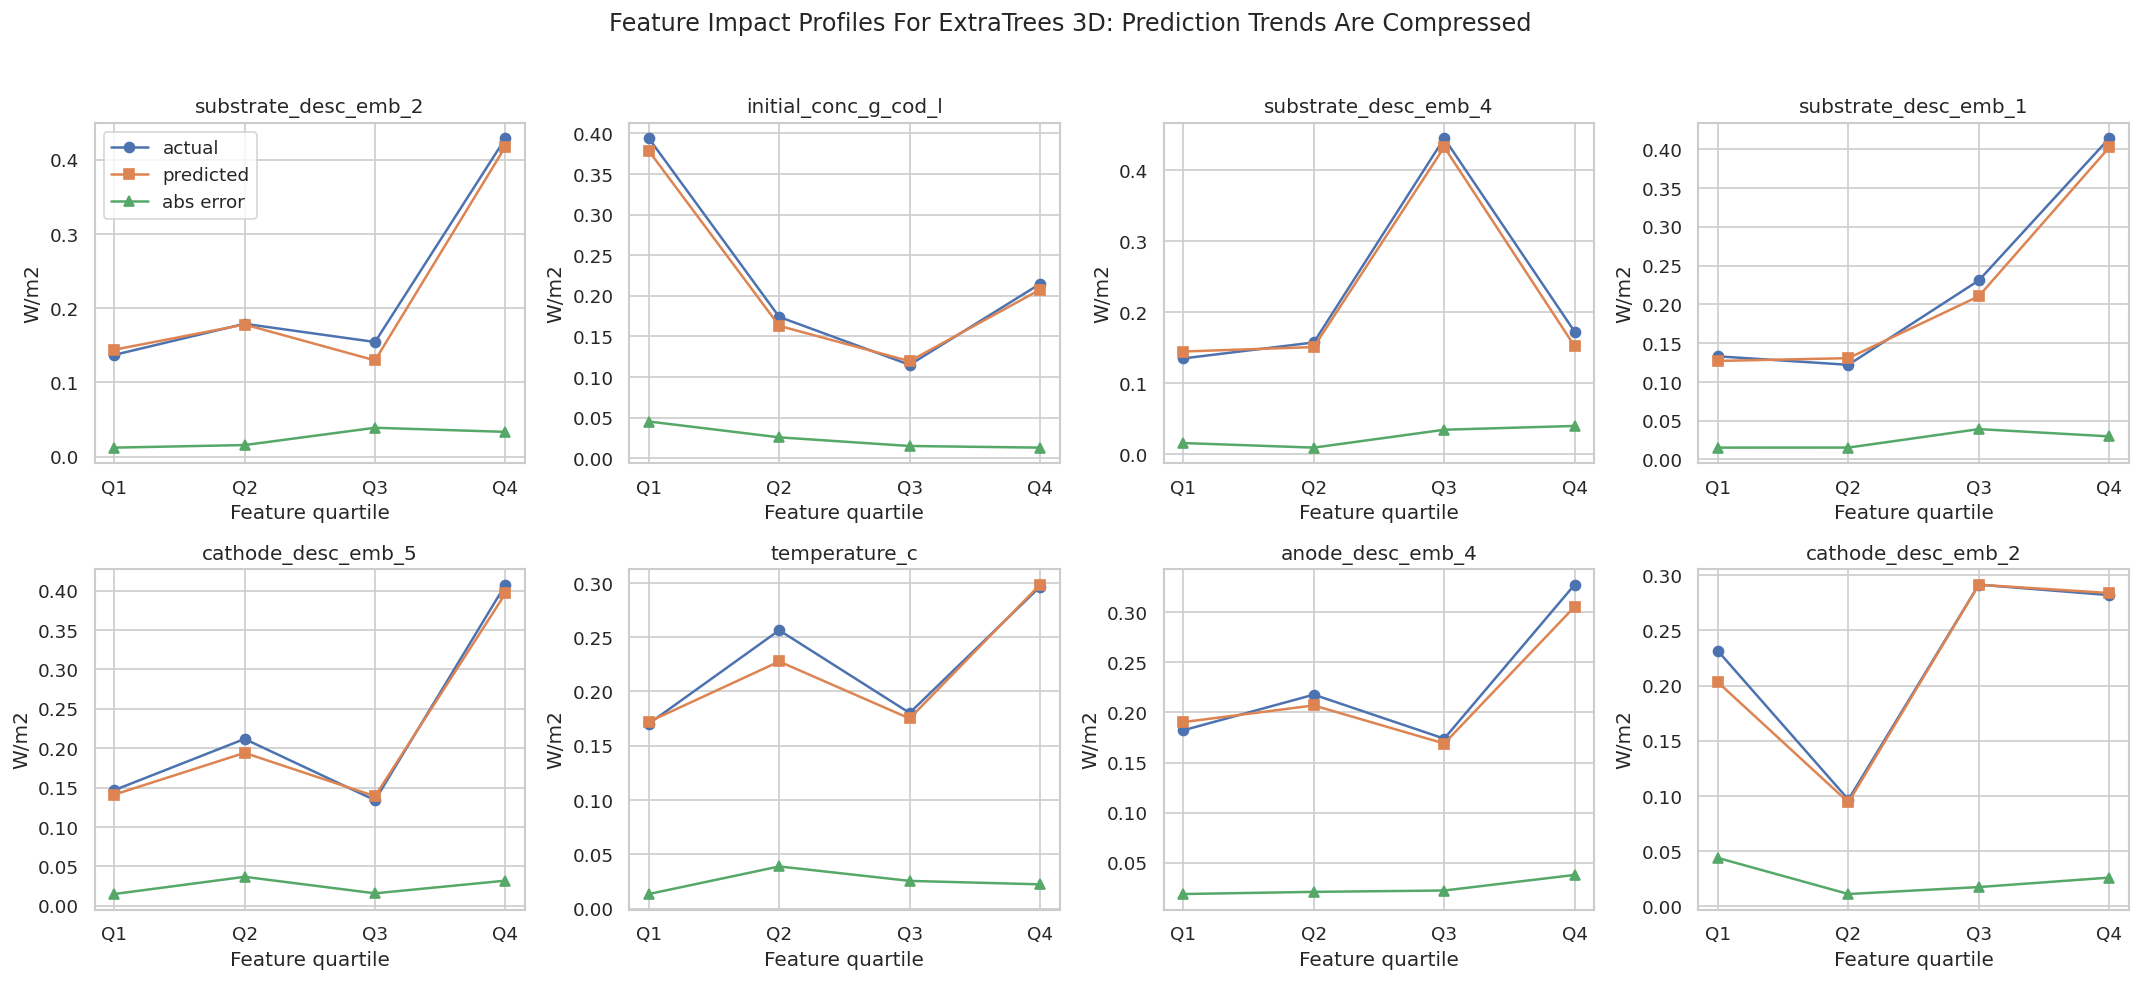

In [7]:
# Observational feature-impact profiles: not causal. They show whether important features separate actual/predicted target levels.
PROFILE_RUN_LABEL = "ExtraTrees 3D" if "ExtraTrees 3D" in ordered_loaded_models() else ("ExtraTrees 5D" if "ExtraTrees 5D" in ordered_loaded_models() else (ordered_loaded_models()[0] if len(ordered_loaded_models()) > 0 else ""))
profile_run = runs[PROFILE_RUN_LABEL]
profile_data_dir = ML_READY_DIR / profile_run["metrics"]["run_name"]
train_features = pd.read_csv(profile_data_dir / "train_features.csv", encoding="utf-8-sig")
test_features = pd.read_csv(profile_data_dir / "test_features.csv", encoding="utf-8-sig")
features_all = pd.concat([train_features, test_features], ignore_index=True)
pred_all = pd.concat([profile_run["train"], profile_run["test"]], ignore_index=True)
profile_df = features_all.drop(columns=[TARGET_COL]).copy()
profile_df["actual"] = pred_all["actual"].to_numpy()
profile_df["predicted"] = pred_all["predicted"].to_numpy()
profile_df["abs_error"] = (profile_df["actual"] - profile_df["predicted"]).abs()

imp = profile_run["importance"].sort_values("importance", ascending=False).head(8)
profile_features = imp["feature"].tolist()

corr_rows = []
for feature in profile_features:
    corr_rows.append({
        "feature": feature,
        "importance": float(imp.loc[imp["feature"] == feature, "importance"].iloc[0]),
        "spearman_actual": float(profile_df[[feature, "actual"]].corr(method="spearman").iloc[0, 1]),
        "spearman_predicted": float(profile_df[[feature, "predicted"]].corr(method="spearman").iloc[0, 1]),
        "spearman_abs_error": float(profile_df[[feature, "abs_error"]].corr(method="spearman").iloc[0, 1]),
    })
feature_impact_df = pd.DataFrame(corr_rows)
display(feature_impact_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, feature in zip(axes, profile_features):
    tmp = profile_df[[feature, "actual", "predicted", "abs_error"]].copy()
    tmp["feature_bin"] = pd.qcut(tmp[feature].rank(method="first"), q=4, labels=["Q1", "Q2", "Q3", "Q4"])
    agg = tmp.groupby("feature_bin", observed=False)[["actual", "predicted", "abs_error"]].mean().reset_index()
    ax.plot(agg["feature_bin"], agg["actual"], marker="o", label="actual")
    ax.plot(agg["feature_bin"], agg["predicted"], marker="s", label="predicted")
    ax.plot(agg["feature_bin"], agg["abs_error"], marker="^", label="abs error")
    ax.set_title(feature)
    ax.set_xlabel("Feature quartile")
    ax.set_ylabel("W/m2")
axes[0].legend()
fig.suptitle(f"Feature Impact Profiles For {PROFILE_RUN_LABEL}: Prediction Trends Are Compressed", y=1.02)
fig.tight_layout()
fig.savefig(DIAG_DIR / "06_feature_impact_profiles.png", dpi=200, bbox_inches="tight")


## Cross-model sample-level diagnostics

This cell aligns all holdout-test predictions sample-by-sample. It highlights whether errors are model-specific or shared by most models, which is stronger evidence for a data/feature limitation.


,test_id,actual,target_bin,model_pred_mean,model_pred_std,mean_abs_error_across_models,all_models_underpredict,pred_XGB 3D,pred_CatBoost 3D,pred_ExtraTrees 3D
2,2,1.000000e+00,0.5-1.0,1.311586,0.227328,0.311586,False,1.327095,1.581926,1.025736
3,3,5.500000e-01,0.5-1.0,0.571696,0.074067,0.061812,False,0.506327,0.533499,0.675261
12,12,3.290000e-01,0.2-0.5,0.188325,0.026258,0.140675,True,0.165373,0.174519,0.225083
5,5,2.260000e-01,0.2-0.5,0.250190,0.066611,0.069942,False,0.282670,0.310528,0.157371
10,10,7.110000e-02,0.05-0.1,0.036492,0.017636,0.034608,True,0.014576,0.037140,0.057760
6,6,6.575000e-02,0.05-0.1,0.033936,0.005759,0.031814,True,0.039934,0.026167,0.035708
7,7,6.400000e-02,0.05-0.1,0.031975,0.010214,0.032025,True,0.045895,0.021672,0.028357
8,8,5.925000e-02,0.05-0.1,0.064859,0.013742,0.014207,False,0.046353,0.068973,0.079250
14,14,5.620000e-02,0.05-0.1,0.068035,0.006971,0.011835,False,0.075781,0.069444,0.058881
1,1,3.300000e-02,0.01-0.05,0.102092,0.004683,0.069092,False,0.108373,0.100771,0.097133


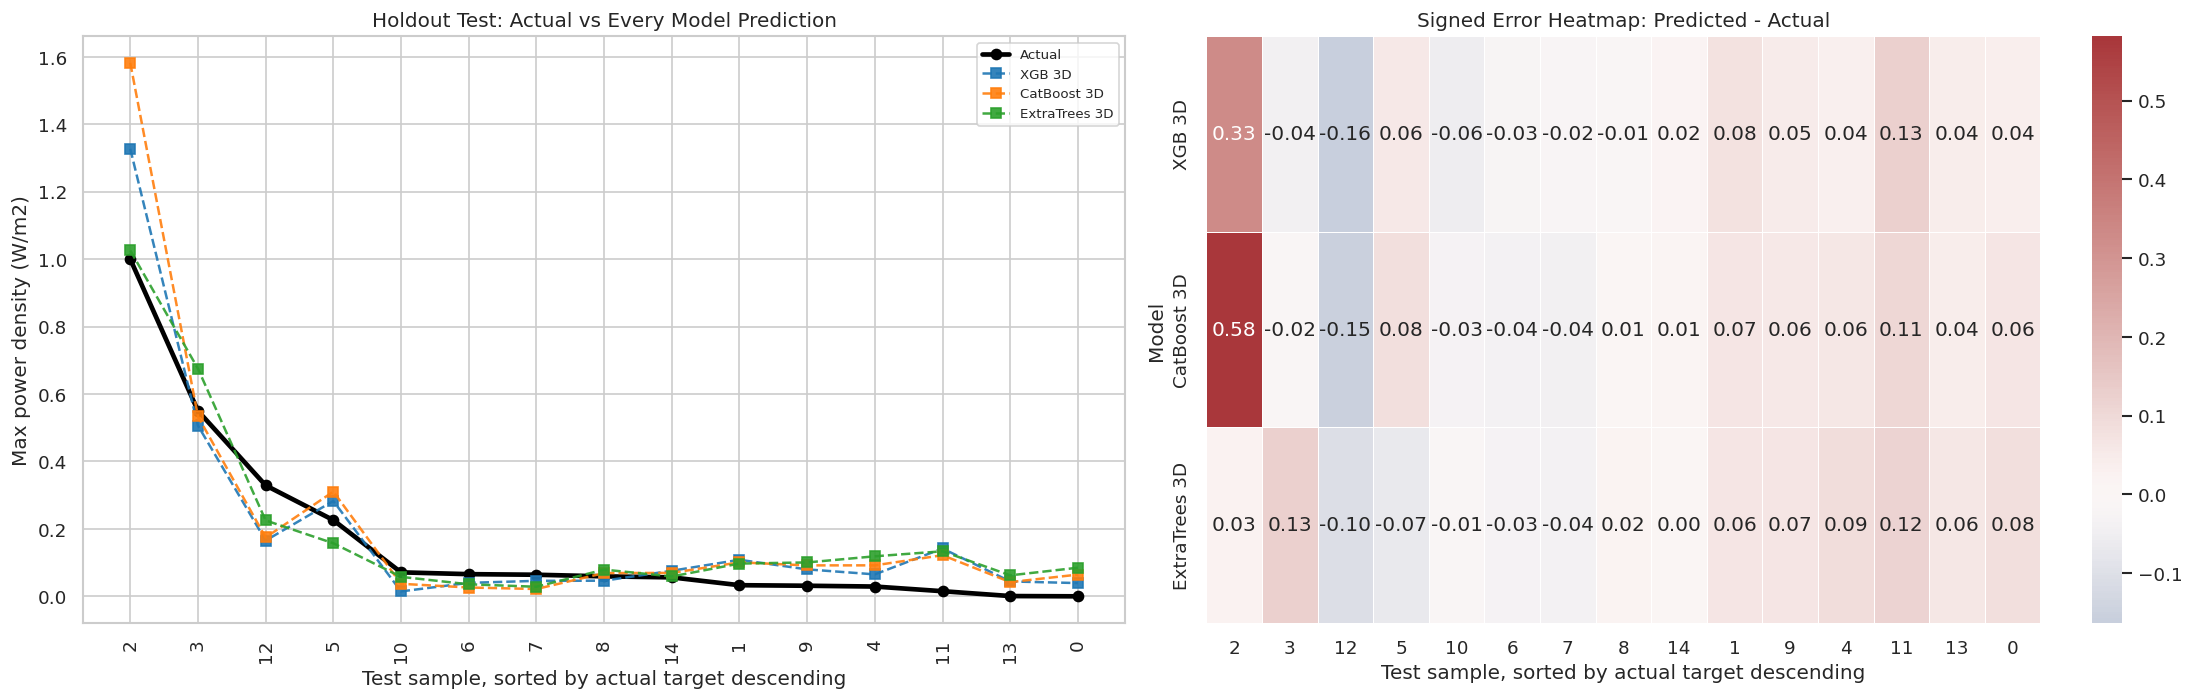

In [8]:
sample_rows = []
model_labels = ordered_loaded_models()
reference_label = "ExtraTrees 3D" if "ExtraTrees 3D" in runs else ("ExtraTrees 5D" if "ExtraTrees 5D" in runs else model_labels[0])
reference_test = runs[reference_label]["test"].reset_index(drop=True).copy()

for sample_id in range(len(reference_test)):
    base = {
        "test_id": sample_id,
        "actual": float(reference_test.loc[sample_id, "actual"]),
        "target_bin": str(pd.cut([reference_test.loc[sample_id, "actual"]], TARGET_BINS, labels=TARGET_BIN_LABELS)[0]),
    }
    for col in SOURCE_COLS:
        if col in reference_test.columns:
            base[col] = reference_test.loc[sample_id, col]
    preds = []
    abs_errors = []
    for label in model_labels:
        pred_df = runs[label]["test"].reset_index(drop=True)
        pred = float(pred_df.loc[sample_id, "predicted"])
        base[f"pred_{label}"] = pred
        base[f"abs_error_{label}"] = abs(pred - base["actual"])
        preds.append(pred)
        abs_errors.append(abs(pred - base["actual"]))
    base["model_pred_mean"] = float(np.mean(preds))
    base["model_pred_std"] = float(np.std(preds, ddof=0))
    base["mean_abs_error_across_models"] = float(np.mean(abs_errors))
    base["all_models_underpredict"] = bool(all(pred < base["actual"] for pred in preds))
    sample_rows.append(base)

sample_error_df = pd.DataFrame(sample_rows).sort_values("actual", ascending=False)
display_cols = ["test_id", "actual", "target_bin", "model_pred_mean", "model_pred_std", "mean_abs_error_across_models", "all_models_underpredict"]
display_cols += [f"pred_{label}" for label in model_labels]
display(sample_error_df[display_cols].head(20))

plot_df = []
for _, row in sample_error_df.iterrows():
    plot_df.append({"test_id": row["test_id"], "model": "Actual", "value": row["actual"]})
    for label in model_labels:
        plot_df.append({"test_id": row["test_id"], "model": label, "value": row[f"pred_{label}"]})
plot_df = pd.DataFrame(plot_df)
ordered_ids = sample_error_df["test_id"].tolist()
plot_df["test_id"] = pd.Categorical(plot_df["test_id"], ordered_ids, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(19, 6))
for model in ["Actual"] + model_labels:
    sub = plot_df[plot_df["model"] == model]
    if model == "Actual":
        axes[0].plot(sub["test_id"].astype(str), sub["value"], color="black", marker="o", linewidth=2.8, label="Actual")
    else:
        axes[0].plot(sub["test_id"].astype(str), sub["value"], color=MODEL_COLORS[model], marker="s", linestyle="--", linewidth=1.5, alpha=0.9, label=model)
axes[0].set_title("Holdout Test: Actual vs Every Model Prediction")
axes[0].set_xlabel("Test sample, sorted by actual target descending")
axes[0].set_ylabel("Max power density (W/m2)")
axes[0].tick_params(axis="x", rotation=90)
axes[0].legend(fontsize=8)

signed_error_matrix = []
for label in model_labels:
    err = []
    pred_df = runs[label]["test"].reset_index(drop=True)
    for sample_id in ordered_ids:
        err.append(float(pred_df.loc[sample_id, "predicted"] - pred_df.loc[sample_id, "actual"]))
    signed_error_matrix.append(err)
signed_error_matrix = pd.DataFrame(signed_error_matrix, index=model_labels, columns=[str(i) for i in ordered_ids])
sns.heatmap(signed_error_matrix, center=0, cmap="vlag", annot=True, fmt=".2f", linewidths=0.4, ax=axes[1])
axes[1].set_title("Signed Error Heatmap: Predicted - Actual")
axes[1].set_xlabel("Test sample, sorted by actual target descending")
axes[1].set_ylabel("Model")

fig.tight_layout()
fig.savefig(DIAG_DIR / "07_cross_model_sample_error_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


## Train-coverage and nearest-neighbor diagnostics

This cell checks whether high test errors happen because test samples are far from the train feature space, or because the nearest train samples still have very different target values. It uses only prepared numeric ML features and saved predictions.


,test_id,actual,nearest_train_distance,nearest_train_target,target_gap_to_nearest_train,target_bin
0,0,2.300000e-08,3.933167,0.692000,0.692000,<=0.01
12,12,3.290000e-01,3.230858,0.836000,0.507000,0.2-0.5
3,3,5.500000e-01,1.289043,0.720000,0.170000,0.5-1.0
9,9,3.137000e-02,3.108760,0.152550,0.121180,0.01-0.05
6,6,6.575000e-02,1.519793,0.001150,0.064600,0.05-0.1
7,7,6.400000e-02,1.248301,0.002900,0.061100,0.05-0.1
1,1,3.300000e-02,0.067101,0.091000,0.058000,0.01-0.05
2,2,1.000000e+00,1.933565,1.050000,0.050000,0.5-1.0
5,5,2.260000e-01,3.903439,0.270000,0.044000,0.2-0.5
8,8,5.925000e-02,1.439754,0.023500,0.035750,0.05-0.1


,model,spearman_error_vs_distance,spearman_error_vs_target_gap,mean_abs_error
0,CatBoost 3D,0.557143,0.257373,0.091987
1,ExtraTrees 3D,0.557143,0.487936,0.060858
2,XGB 3D,0.307143,0.087578,0.072885


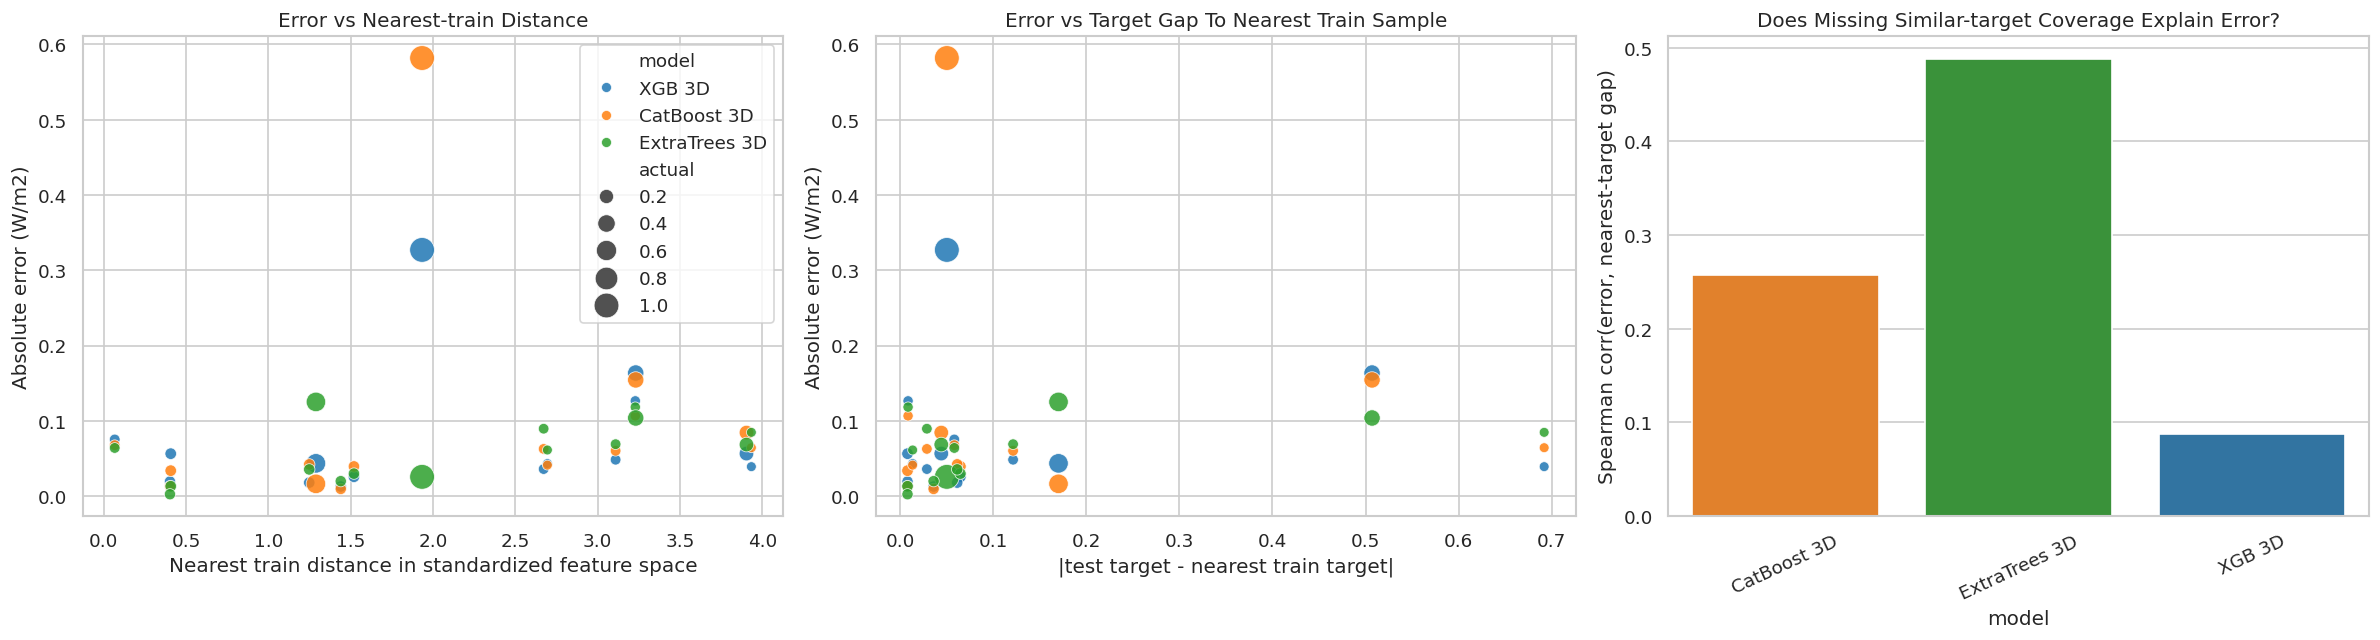

In [10]:
PROFILE_DATASET_NAME = "pca_5d_iterative_extra_trees"
profile_data_dir = ML_READY_DIR / PROFILE_DATASET_NAME
train_features_nn = pd.read_csv(profile_data_dir / "train_features.csv", encoding="utf-8-sig")
test_features_nn = pd.read_csv(profile_data_dir / "test_features.csv", encoding="utf-8-sig")
feature_cols_nn = [c for c in train_features_nn.columns if c != TARGET_COL]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_features_nn[feature_cols_nn])
X_test_scaled = scaler.transform(test_features_nn[feature_cols_nn])
distances = pairwise_distances(X_test_scaled, X_train_scaled, metric="euclidean")
nearest_idx = distances.argmin(axis=1)
nearest_distance = distances.min(axis=1)
nearest_train_target = train_features_nn.iloc[nearest_idx][TARGET_COL].to_numpy(dtype=float)

test_actual = test_features_nn[TARGET_COL].to_numpy(dtype=float)
coverage_df = pd.DataFrame({
    "test_id": np.arange(len(test_features_nn)),
    "actual": test_actual,
    "nearest_train_distance": nearest_distance,
    "nearest_train_target": nearest_train_target,
    "target_gap_to_nearest_train": np.abs(test_actual - nearest_train_target),
    "target_bin": pd.cut(test_actual, TARGET_BINS, labels=TARGET_BIN_LABELS).astype(str),
})

coverage_long = []
for label in model_labels:
    pred_df = runs[label]["test"].reset_index(drop=True)
    tmp = coverage_df.copy()
    tmp["model"] = label
    tmp["predicted"] = pred_df["predicted"].to_numpy(dtype=float)
    tmp["abs_error"] = np.abs(tmp["actual"] - tmp["predicted"])
    coverage_long.append(tmp)
coverage_long_df = pd.concat(coverage_long, ignore_index=True)

display(coverage_df.sort_values(["target_gap_to_nearest_train", "nearest_train_distance"], ascending=False).head(12))

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
sns.scatterplot(
    data=coverage_long_df,
    x="nearest_train_distance",
    y="abs_error",
    hue="model",
    size="actual",
    sizes=(35, 220),
    palette=MODEL_COLORS,
    alpha=0.85,
    ax=axes[0],
)
axes[0].set_title("Error vs Nearest-train Distance")
axes[0].set_xlabel("Nearest train distance in standardized feature space")
axes[0].set_ylabel("Absolute error (W/m2)")

sns.scatterplot(
    data=coverage_long_df,
    x="target_gap_to_nearest_train",
    y="abs_error",
    hue="model",
    size="actual",
    sizes=(35, 220),
    palette=MODEL_COLORS,
    alpha=0.85,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Error vs Target Gap To Nearest Train Sample")
axes[1].set_xlabel("|test target - nearest train target|")
axes[1].set_ylabel("Absolute error (W/m2)")

nn_summary = coverage_long_df.groupby("model", as_index=False).agg(
    spearman_error_vs_distance=("nearest_train_distance", lambda s: s.corr(coverage_long_df.loc[s.index, "abs_error"], method="spearman")),
    spearman_error_vs_target_gap=("target_gap_to_nearest_train", lambda s: s.corr(coverage_long_df.loc[s.index, "abs_error"], method="spearman")),
    mean_abs_error=("abs_error", "mean"),
)
sns.barplot(data=nn_summary, x="model", y="spearman_error_vs_target_gap", hue="model", palette=MODEL_COLORS, dodge=False, legend=False, ax=axes[2])
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Does Missing Similar-target Coverage Explain Error?")
axes[2].tick_params(axis="x", rotation=25)
axes[2].set_ylabel("Spearman corr(error, nearest-target gap)")

display(nn_summary)
fig.tight_layout()
fig.savefig(DIAG_DIR / "08_train_coverage_nearest_neighbor_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()


## Cross-model feature-bin bias profiles

The last original cell profiles one reference model. This cell extends that idea across the comparable 5D models and asks: for the most repeatedly important features, do models track the actual target trend or collapse toward the mean?


,feature,mean_rank,n_models,mean_importance
21,substrate_desc_emb_4,2.333333,3,3.060935
13,cathode_desc_emb_5,3.666667,3,2.487771
19,substrate_desc_emb_2,4.000000,3,2.045424
16,initial_conc_g_cod_l,4.333333,3,2.218380
23,temperature_c,6.000000,3,2.329325
18,substrate_desc_emb_1,7.333333,3,1.876607


,model,feature_bin,actual_mean,predicted_mean,abs_error_mean,n,feature,bias_pred_minus_actual
0,CatBoost 3D,Q1,0.134943,0.136844,0.028833,25,substrate_desc_emb_4,0.001901
1,CatBoost 3D,Q2,0.157436,0.140609,0.035364,24,substrate_desc_emb_4,-0.016827
2,CatBoost 3D,Q3,0.445140,0.423144,0.126917,24,substrate_desc_emb_4,-0.021997
3,CatBoost 3D,Q4,0.172611,0.146523,0.056659,25,substrate_desc_emb_4,-0.026088
4,ExtraTrees 3D,Q1,0.134943,0.144665,0.015699,25,substrate_desc_emb_4,0.009722
5,ExtraTrees 3D,Q2,0.157436,0.150954,0.009229,24,substrate_desc_emb_4,-0.006482
6,ExtraTrees 3D,Q3,0.445140,0.432756,0.034454,24,substrate_desc_emb_4,-0.012384
7,ExtraTrees 3D,Q4,0.172611,0.152097,0.039784,25,substrate_desc_emb_4,-0.020514
8,XGB 3D,Q1,0.134943,0.130487,0.038481,25,substrate_desc_emb_4,-0.004456
9,XGB 3D,Q2,0.157436,0.138109,0.040953,24,substrate_desc_emb_4,-0.019327


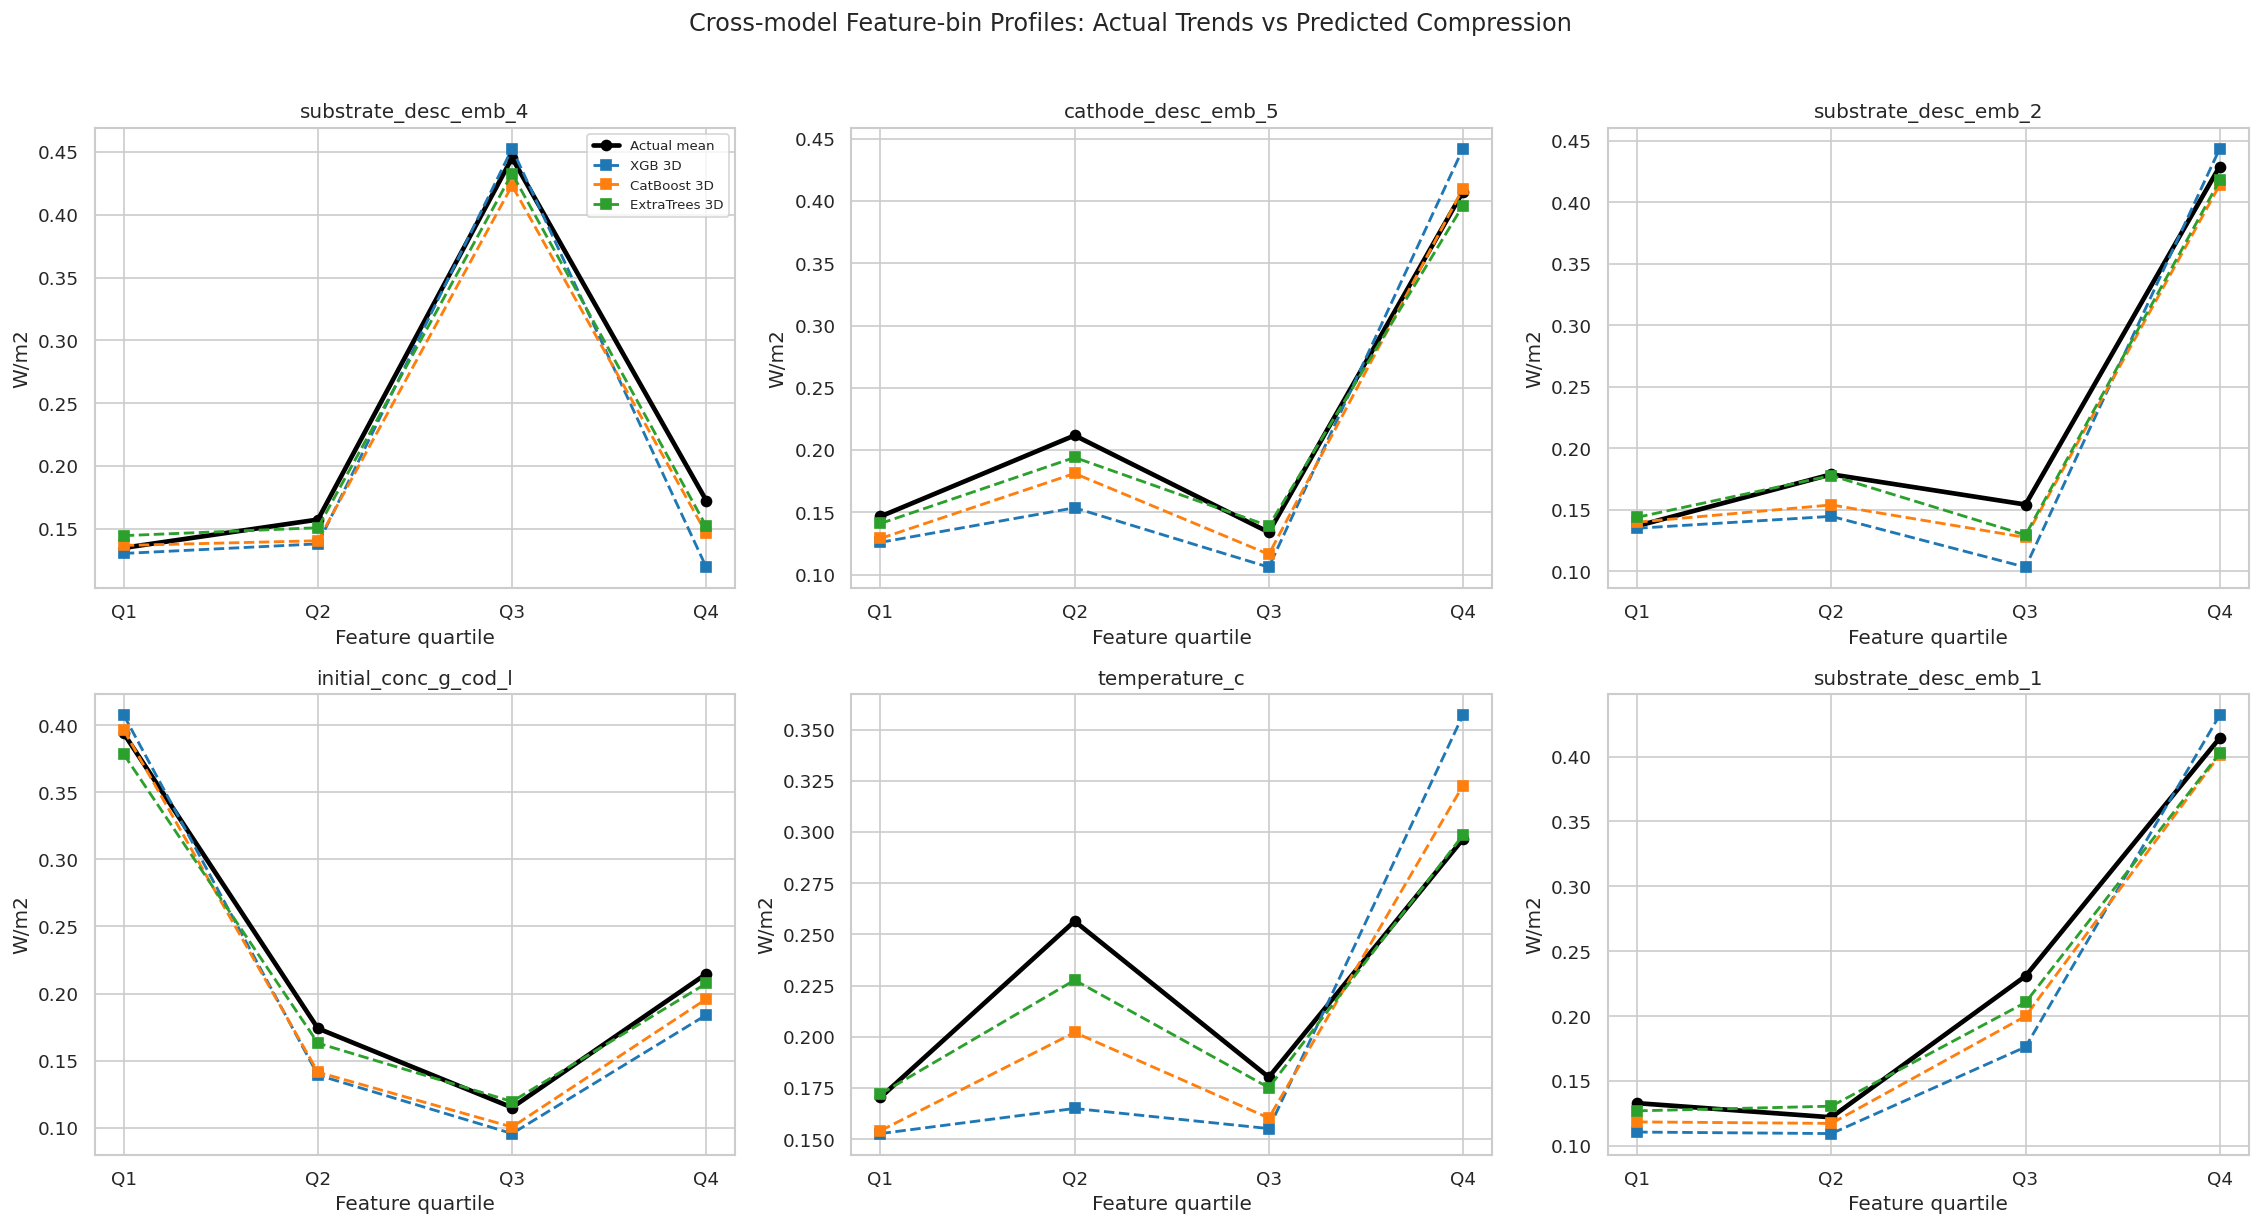

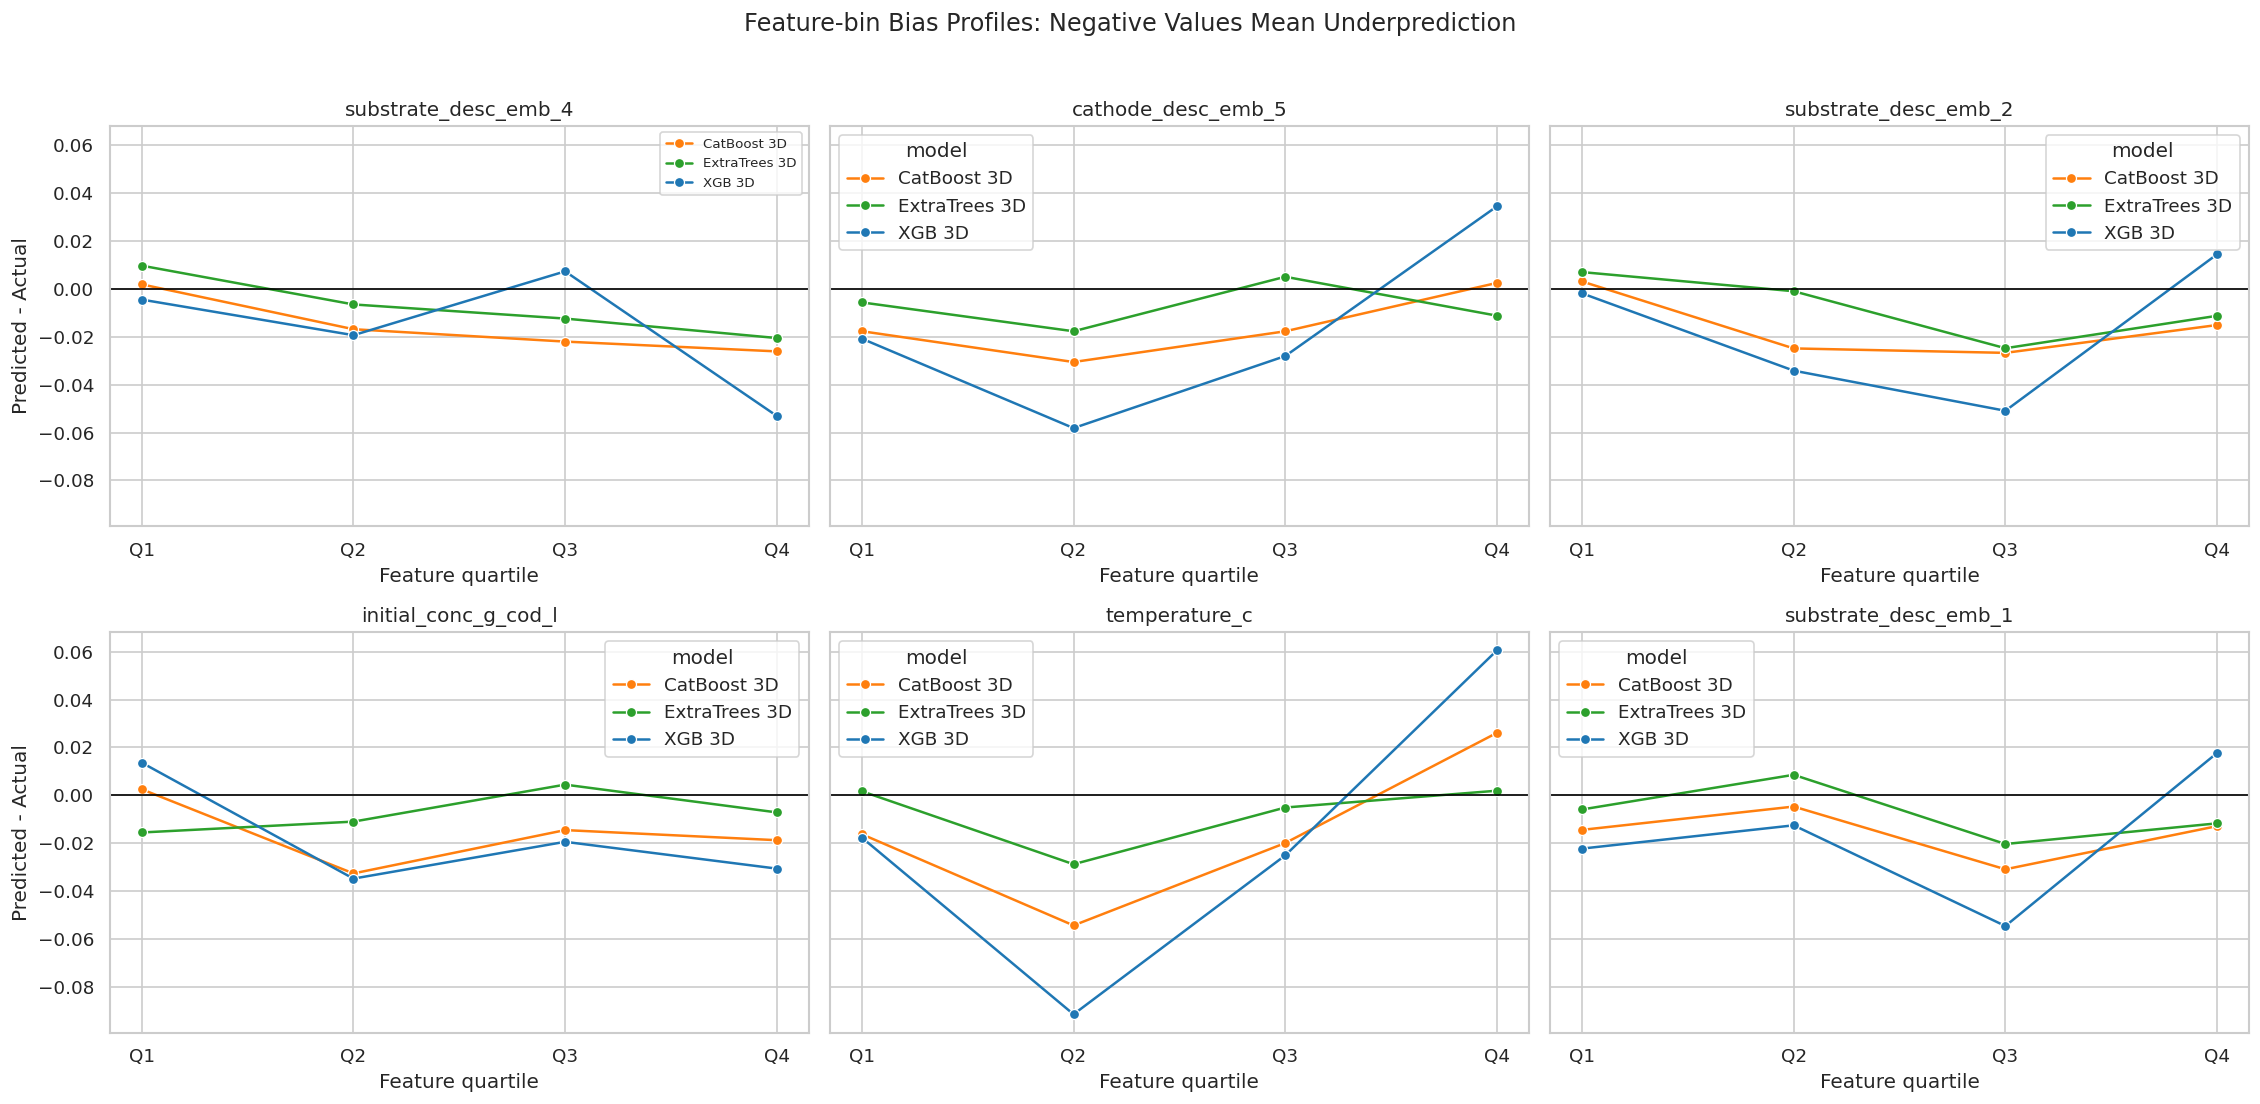

In [12]:
COMPARABLE_RUN_NAME = "pca_5d_iterative_extra_trees"
comparable_labels = [label for label in model_labels if runs[label]["metrics"].get("run_name") == COMPARABLE_RUN_NAME]

rank_parts = []
for label in comparable_labels:
    imp = runs[label]["importance"].copy()
    if imp.empty:
        continue
    importance_col = "importance" if "importance" in imp.columns else "importance_mae_increase_mean"
    imp = imp[["feature", importance_col]].rename(columns={importance_col: "importance_value"})
    imp["model"] = label
    imp["rank"] = imp["importance_value"].rank(method="min", ascending=False)
    rank_parts.append(imp)
rank_df = pd.concat(rank_parts, ignore_index=True)
consensus_features_df = (
    rank_df.groupby("feature", as_index=False)
    .agg(mean_rank=("rank", "mean"), n_models=("model", "nunique"), mean_importance=("importance_value", "mean"))
    .sort_values(["n_models", "mean_rank"], ascending=[False, True])
    .head(6)
)
consensus_features = consensus_features_df["feature"].tolist()
display(consensus_features_df)

all_features = pd.concat([train_features_nn, test_features_nn], ignore_index=True)
feature_base = all_features[consensus_features + [TARGET_COL]].copy()
feature_base["sample_id_all"] = np.arange(len(feature_base))

long_profile_rows = []
for label in comparable_labels:
    pred_all = pd.concat([runs[label]["train"], runs[label]["test"]], ignore_index=True).reset_index(drop=True)
    tmp = feature_base.copy()
    tmp["model"] = label
    tmp["actual"] = pred_all["actual"].to_numpy(dtype=float)
    tmp["predicted"] = pred_all["predicted"].to_numpy(dtype=float)
    tmp["abs_error"] = np.abs(tmp["actual"] - tmp["predicted"])
    long_profile_rows.append(tmp)
profile_long_df = pd.concat(long_profile_rows, ignore_index=True)

agg_rows = []
for feature in consensus_features:
    bins = pd.qcut(feature_base[feature].rank(method="first"), q=4, labels=["Q1", "Q2", "Q3", "Q4"])
    feature_bins = pd.DataFrame({"sample_id_all": feature_base["sample_id_all"], "feature_bin": bins})
    tmp = profile_long_df.merge(feature_bins, on="sample_id_all", how="left")
    grouped = tmp.groupby(["model", "feature_bin"], observed=False).agg(
        actual_mean=("actual", "mean"),
        predicted_mean=("predicted", "mean"),
        abs_error_mean=("abs_error", "mean"),
        n=("actual", "size"),
    ).reset_index()
    grouped["feature"] = feature
    grouped["bias_pred_minus_actual"] = grouped["predicted_mean"] - grouped["actual_mean"]
    agg_rows.append(grouped)
feature_bin_profile_df = pd.concat(agg_rows, ignore_index=True)
display(feature_bin_profile_df.head(24))

fig, axes = plt.subplots(2, 3, figsize=(19, 10), sharey=False)
axes = axes.ravel()
for ax, feature in zip(axes, consensus_features):
    sub = feature_bin_profile_df[feature_bin_profile_df["feature"] == feature]
    actual_line = sub.groupby("feature_bin", observed=False)["actual_mean"].mean().reset_index()
    ax.plot(actual_line["feature_bin"].astype(str), actual_line["actual_mean"], color="black", marker="o", linewidth=2.8, label="Actual mean")
    for label in comparable_labels:
        model_sub = sub[sub["model"] == label]
        ax.plot(model_sub["feature_bin"].astype(str), model_sub["predicted_mean"], color=MODEL_COLORS[label], marker="s", linestyle="--", linewidth=1.7, label=label)
    ax.set_title(feature)
    ax.set_xlabel("Feature quartile")
    ax.set_ylabel("W/m2")
axes[0].legend(fontsize=8)
fig.suptitle("Cross-model Feature-bin Profiles: Actual Trends vs Predicted Compression", y=1.02)
fig.tight_layout()
fig.savefig(DIAG_DIR / "09_cross_model_feature_bin_profiles.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(19, 9), sharey=True)
axes = axes.ravel()
for ax, feature in zip(axes, consensus_features):
    sub = feature_bin_profile_df[feature_bin_profile_df["feature"] == feature]
    sns.lineplot(data=sub, x="feature_bin", y="bias_pred_minus_actual", hue="model", marker="o", palette=MODEL_COLORS, ax=ax)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(feature)
    ax.set_xlabel("Feature quartile")
    ax.set_ylabel("Predicted - Actual")
axes[0].legend(fontsize=8)
fig.suptitle("Feature-bin Bias Profiles: Negative Values Mean Underprediction", y=1.02)
fig.tight_layout()
fig.savefig(DIAG_DIR / "10_cross_model_feature_bin_bias.png", dpi=200, bbox_inches="tight")
plt.show()
